In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import otter
import syncfit
import corner

from astropy.cosmology import Planck18 as cosmo
from astropy import units as u

from emcee import EnsembleSampler
from multiprocessing import Pool

In [2]:
import warnings
db = otter.Otter(datadir="private-data")

Attempting to login to https://otter.idies.jhu.edu/api with the following credentials:
username: user-guest
password: test


## SDSS J1241

In [3]:
j1241 = db.get_phot(names="SDSS_J1241", query_private=True, obs_type="radio", flux_unit="mJy", return_type="pandas")

date_ranges = {
    57459.16642:1,
    57918.05305:2,
    58588.32218:3,
    59545.48532:4,
    60944.95075:5,
    60944.95144:5,
    60944.95214:5,
    60944.95283:5,
    60972.03786:5,
    60972.21166:5,
    60986.12225:5
}

j1241["epoch_num"] = j1241.converted_date.replace(date_ranges)    

j1241.sort_values("converted_date")

Unable to apply the source mapping because 'private'
SDSS_J1241 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.


,name,converted_flux,converted_flux_err,converted_date,converted_wave,converted_freq,converted_flux_unit,converted_date_unit,converted_wave_unit,converted_freq_unit,filter_name,obs_type,upperlimit,reference,human_readable_refs,telescope,epoch_num
14,SDSS_J1241,0.960000,0.016300,57459.16642,4.223024e+07,7.099000,mJy,MJD,nm,GHz,C,radio,False,private,private,NaN,1.0
13,SDSS_J1241,1.502000,0.020100,57459.16642,5.997049e+07,4.999000,mJy,MJD,nm,GHz,C,radio,False,private,private,NaN,1.0
22,SDSS_J1241,0.443300,0.037200,57918.05305,2.725634e+07,10.999000,mJy,MJD,nm,GHz,X,radio,False,private,private,NaN,2.0
20,SDSS_J1241,0.837500,0.031100,57918.05305,4.223024e+07,7.099000,mJy,MJD,nm,GHz,C,radio,False,private,private,NaN,2.0
19,SDSS_J1241,1.217600,0.040400,57918.05305,5.997049e+07,4.999000,mJy,MJD,nm,GHz,C,radio,False,private,private,NaN,2.0
18,SDSS_J1241,2.079700,0.060200,57918.05305,8.509579e+07,3.523000,mJy,MJD,nm,GHz,S,radio,False,private,private,NaN,2.0
17,SDSS_J1241,2.914100,0.081700,57918.05305,1.141197e+08,2.627000,mJy,MJD,nm,GHz,S,radio,False,private,private,NaN,2.0
16,SDSS_J1241,4.125900,0.131700,57918.05305,1.688972e+08,1.775000,mJy,MJD,nm,GHz,L,radio,False,private,private,NaN,2.0
15,SDSS_J1241,4.320300,0.162400,57918.05305,2.306096e+08,1.300000,mJy,MJD,nm,GHz,L,radio,False,private,private,NaN,2.0
21,SDSS_J1241,0.591600,0.029100,57918.05305,3.506755e+07,8.549000,mJy,MJD,nm,GHz,X,radio,False,private,private,NaN,2.0


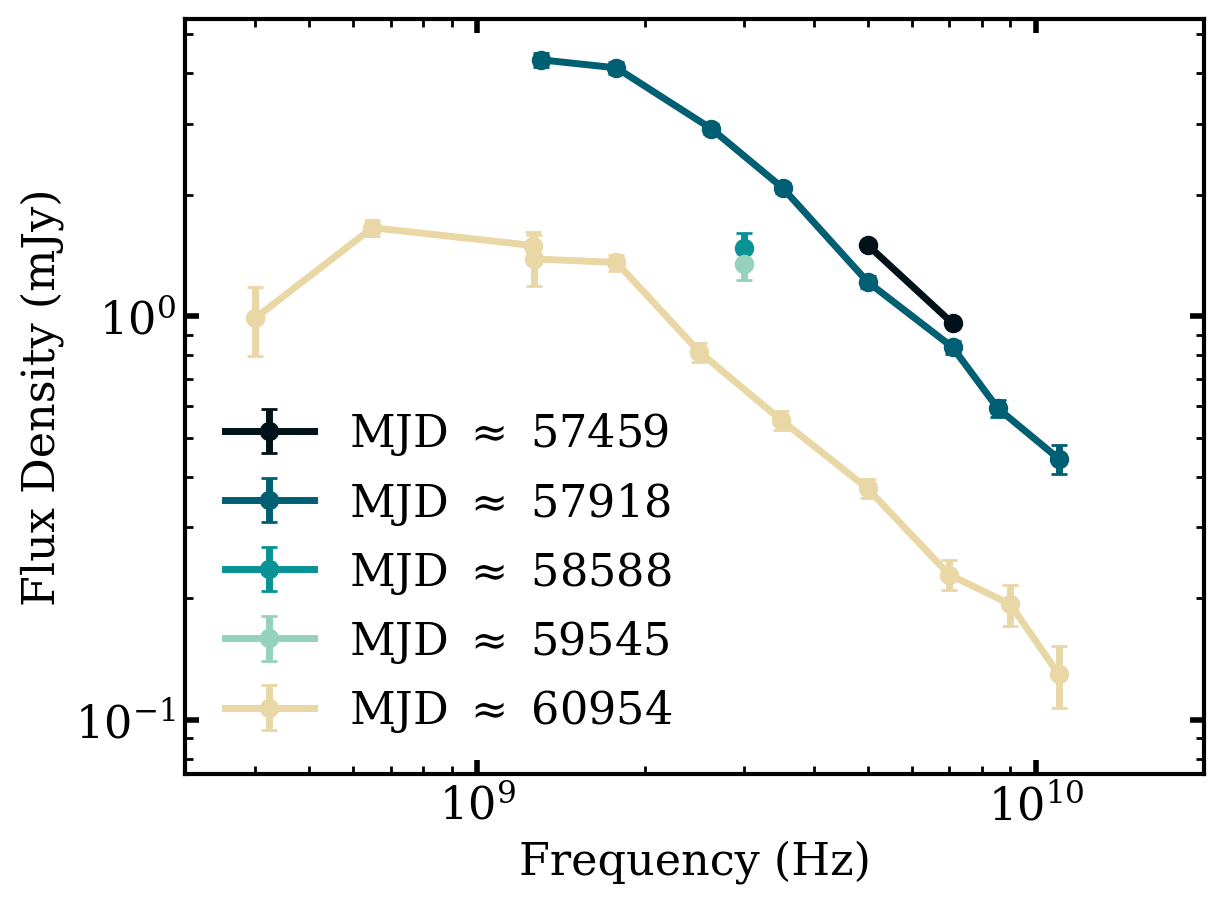

In [4]:
fig, ax = plt.subplots()
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylabel("Flux Density (mJy)")
ax.set_xlabel("Frequency (Hz)")

for epoch_num, grp in j1241.groupby("epoch_num"):
    grp = grp.sort_values("converted_freq")
    ax.errorbar(
        grp.converted_freq*1e9,
        grp.converted_flux,
        yerr = grp.converted_flux_err,
        marker = "o",
        linestyle = "-",
        label = rf"MJD $\approx$ {grp.converted_date.mean():.0f}"
    )

ax.set_xlim(3e8, 2e10)
ax.legend()

In [5]:
prior = dict(
    p=[2,4],
    log_bG_sh=[-4, 2],
    log_Mdot=[-14, -8],
    log_epsilon_T=[-4, -1],
    t=[0, 10_000]
)

model = syncfit.models.MQModel(prior=prior)


def epsB(eps_e, p):
    return (11/(2*(p+1)) + 1)**-1

def lnprior(theta):
    packed_theta = model.pack_theta(theta)
    for label, val in packed_theta.items():
        if val < min(prior[label]) or val > max(prior[label]):
            return -np.inf
    return 0

def loglik(theta, nu, flux, flux_err):
    packed_theta = model.pack_theta(theta)

    if "log_epsilon_e" in fixed_values:
        # then compute log_epsilon_B
        fixed_values["log_epsilon_B"] = np.log10(
            epsB(
                10**fixed_values["log_epsilon_e"], 
                packed_theta["p"]
            )
        )
        # print(fixed_values)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model_result = model.SED(nu, lum_dist=lum_dist.cgs.value, **packed_theta, **fixed_values)
        
    if not np.any(np.isfinite(model_result)):
        ll = -np.inf
    else:    
        sigma2 = flux_err**2
    
        chi2 = np.sum((flux - model_result)**2/sigma2 + np.log(sigma2))
        ll = -0.5*chi2
    return ll

def lnprob(theta, nu, flux, flux_err):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + loglik(theta, nu, flux, flux_err)

In [6]:
z = db.get_meta(names="SDSS_J1241", query_private=True)[0].get_redshift()


100%|███████████████████████████████████████| 5000/5000 [02:21<00:00, 35.41it/s]


Epoch 2:
p = 3.2542228987570687 (+0.4277840011609051, -0.48206372882049164)
log_bG_sh = -1.213133932153529 (+0.36703756060361514, -0.5224323693680484)
log_Mdot = -10.39423162672146 (+0.6407460161161627, -0.5773010346696914)
log_epsilon_T = -2.5809864636631508 (+1.0028076090879399, -0.9560866667029679)
t = 5000.033858951942 (+4677.2309965392205, -3327.074912037706)


/home/nfranz/research/alexander-group/syncfit/src/syncfit/models/thermal_util.py:659: RuntimeWarning: invalid value encountered in multiply
  I = I_of_x(x)*f_fun(Theta)


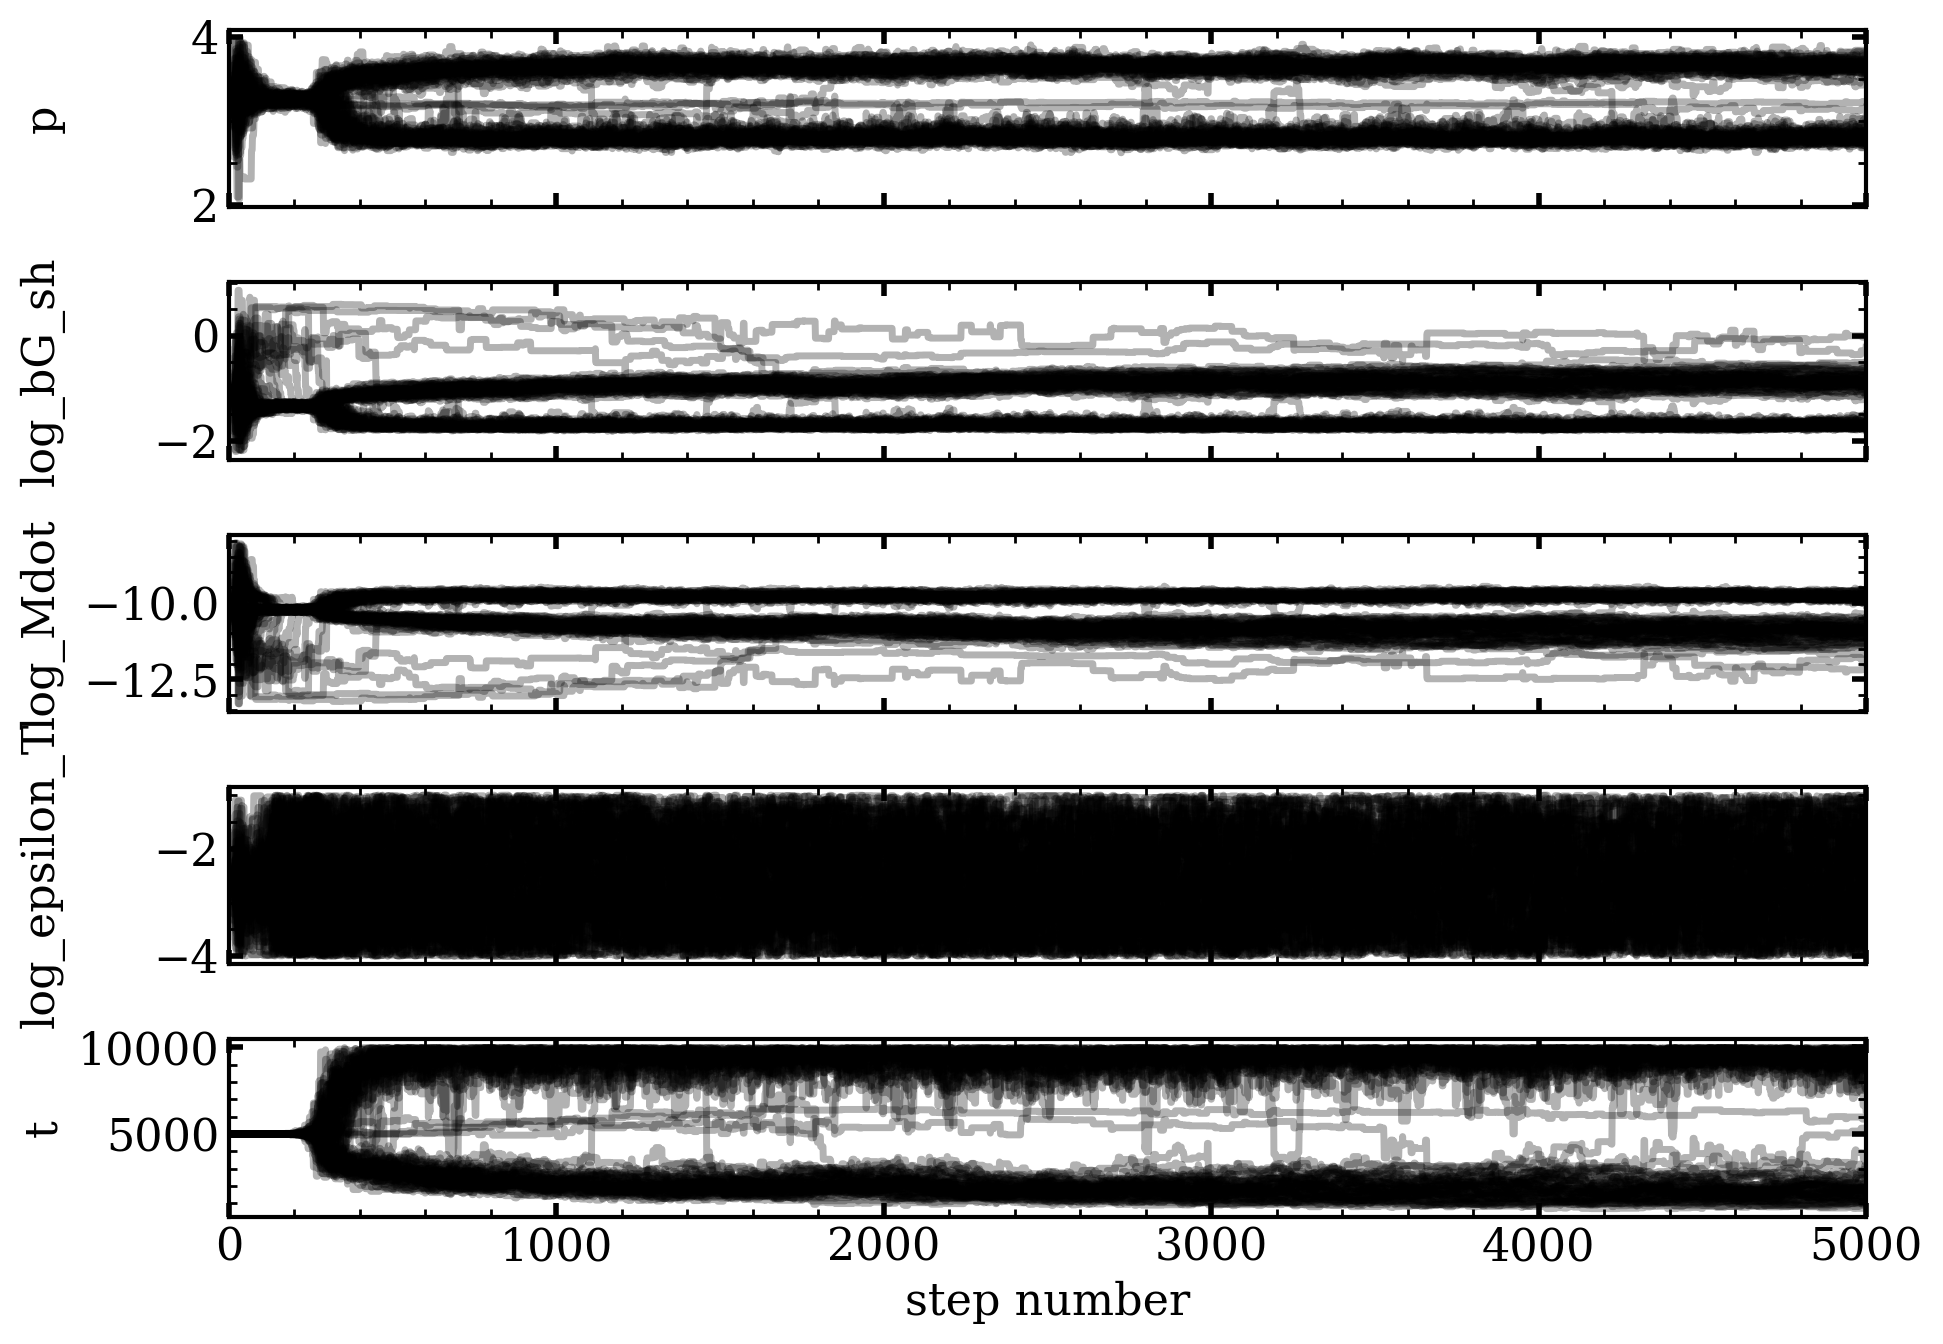

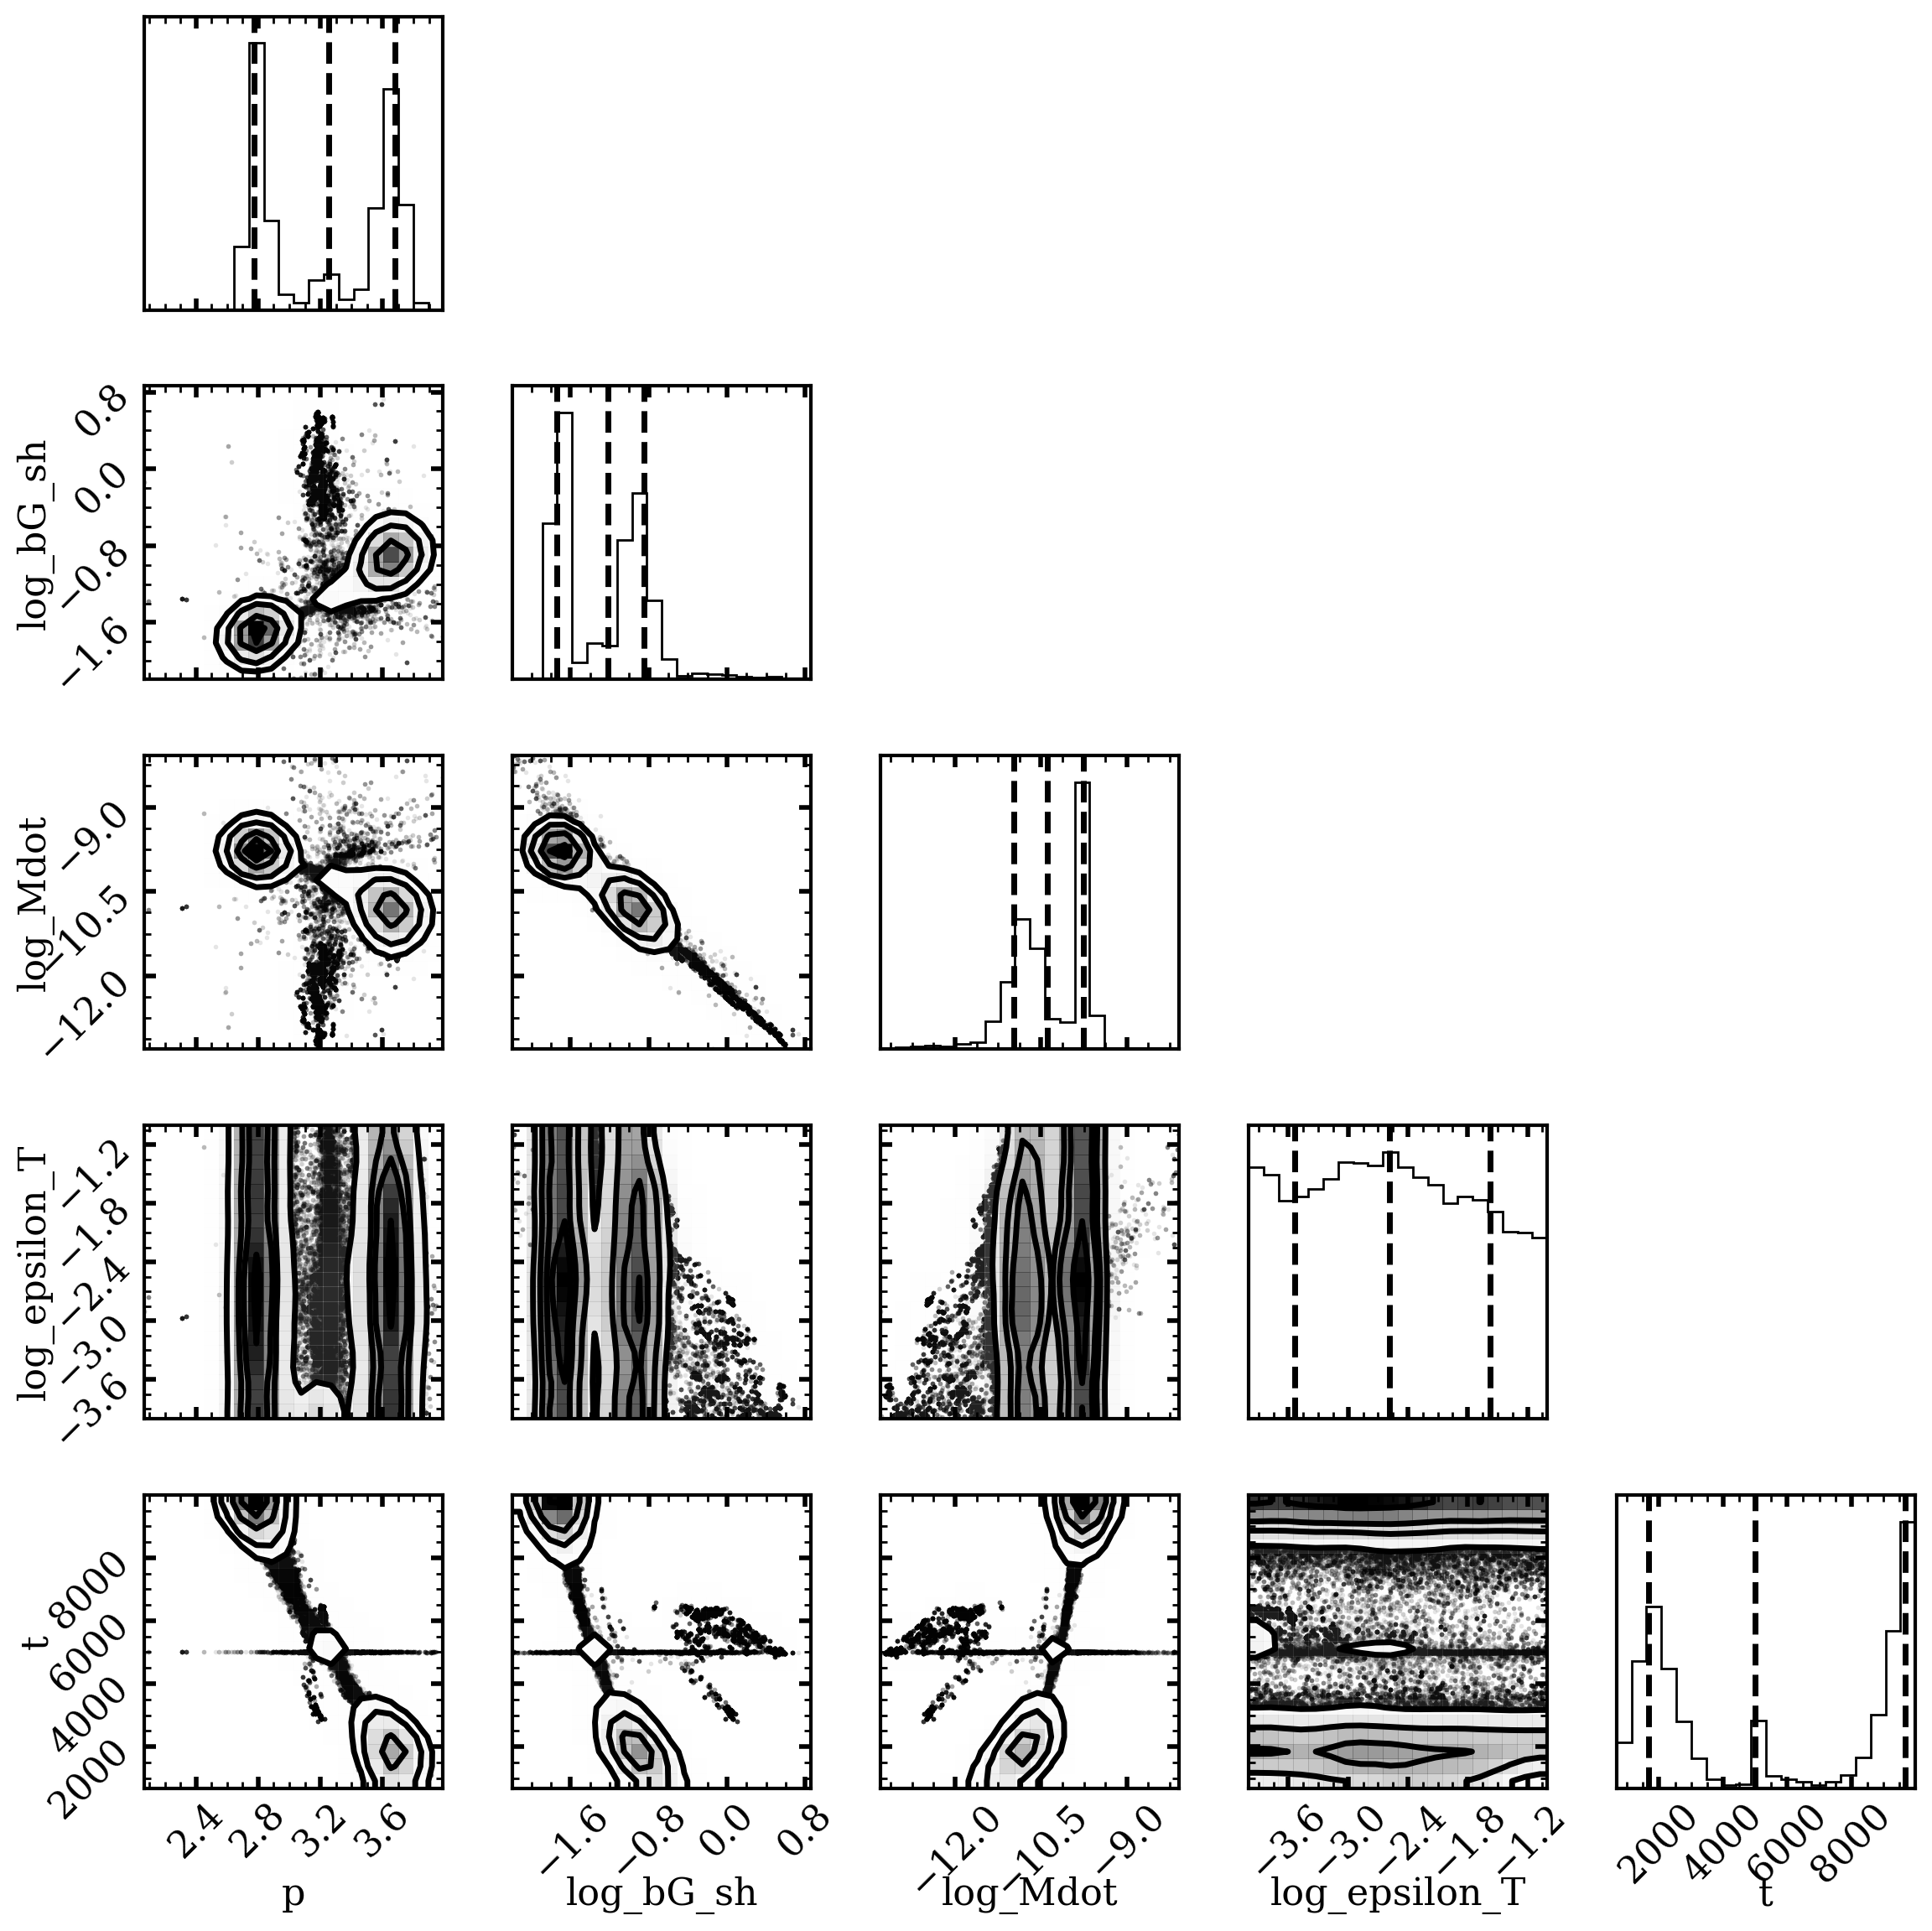

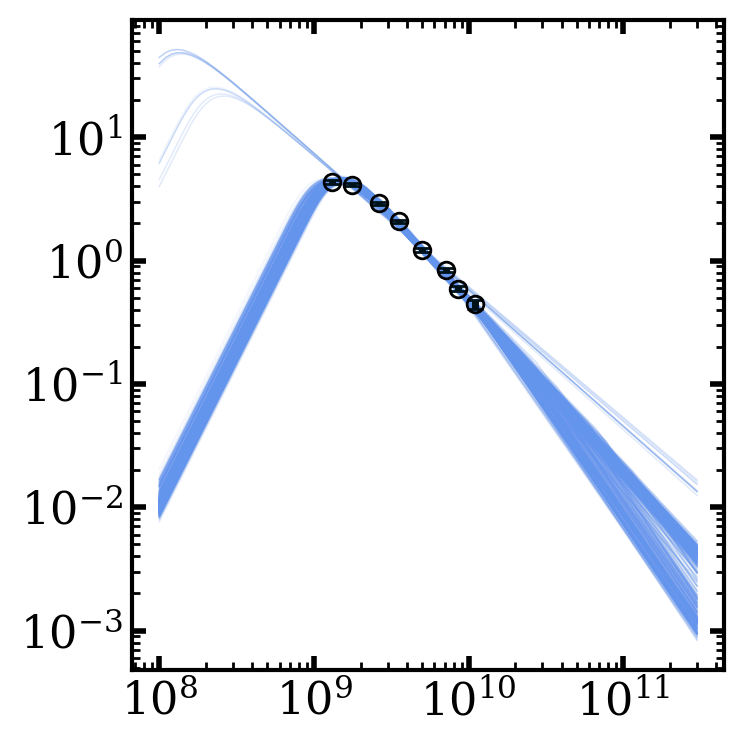

100%|███████████████████████████████████████| 5000/5000 [02:39<00:00, 31.38it/s]


Epoch 5:
p = 3.315277381243949 (+0.09573460281386037, -0.11611434133590182)
log_bG_sh = -1.287852350117181 (+0.2702905242694891, -0.1948271446058334)
log_Mdot = -10.53737259527273 (+0.3284299971825444, -0.5408997263855984)
log_epsilon_T = -2.466664719057415 (+0.9970396724599986, -1.0323057743240334)
t = 4959.0503719940325 (+2067.498875064908, -2140.1399033158714)


/home/nfranz/research/alexander-group/syncfit/src/syncfit/models/thermal_util.py:659: RuntimeWarning: invalid value encountered in multiply
  I = I_of_x(x)*f_fun(Theta)


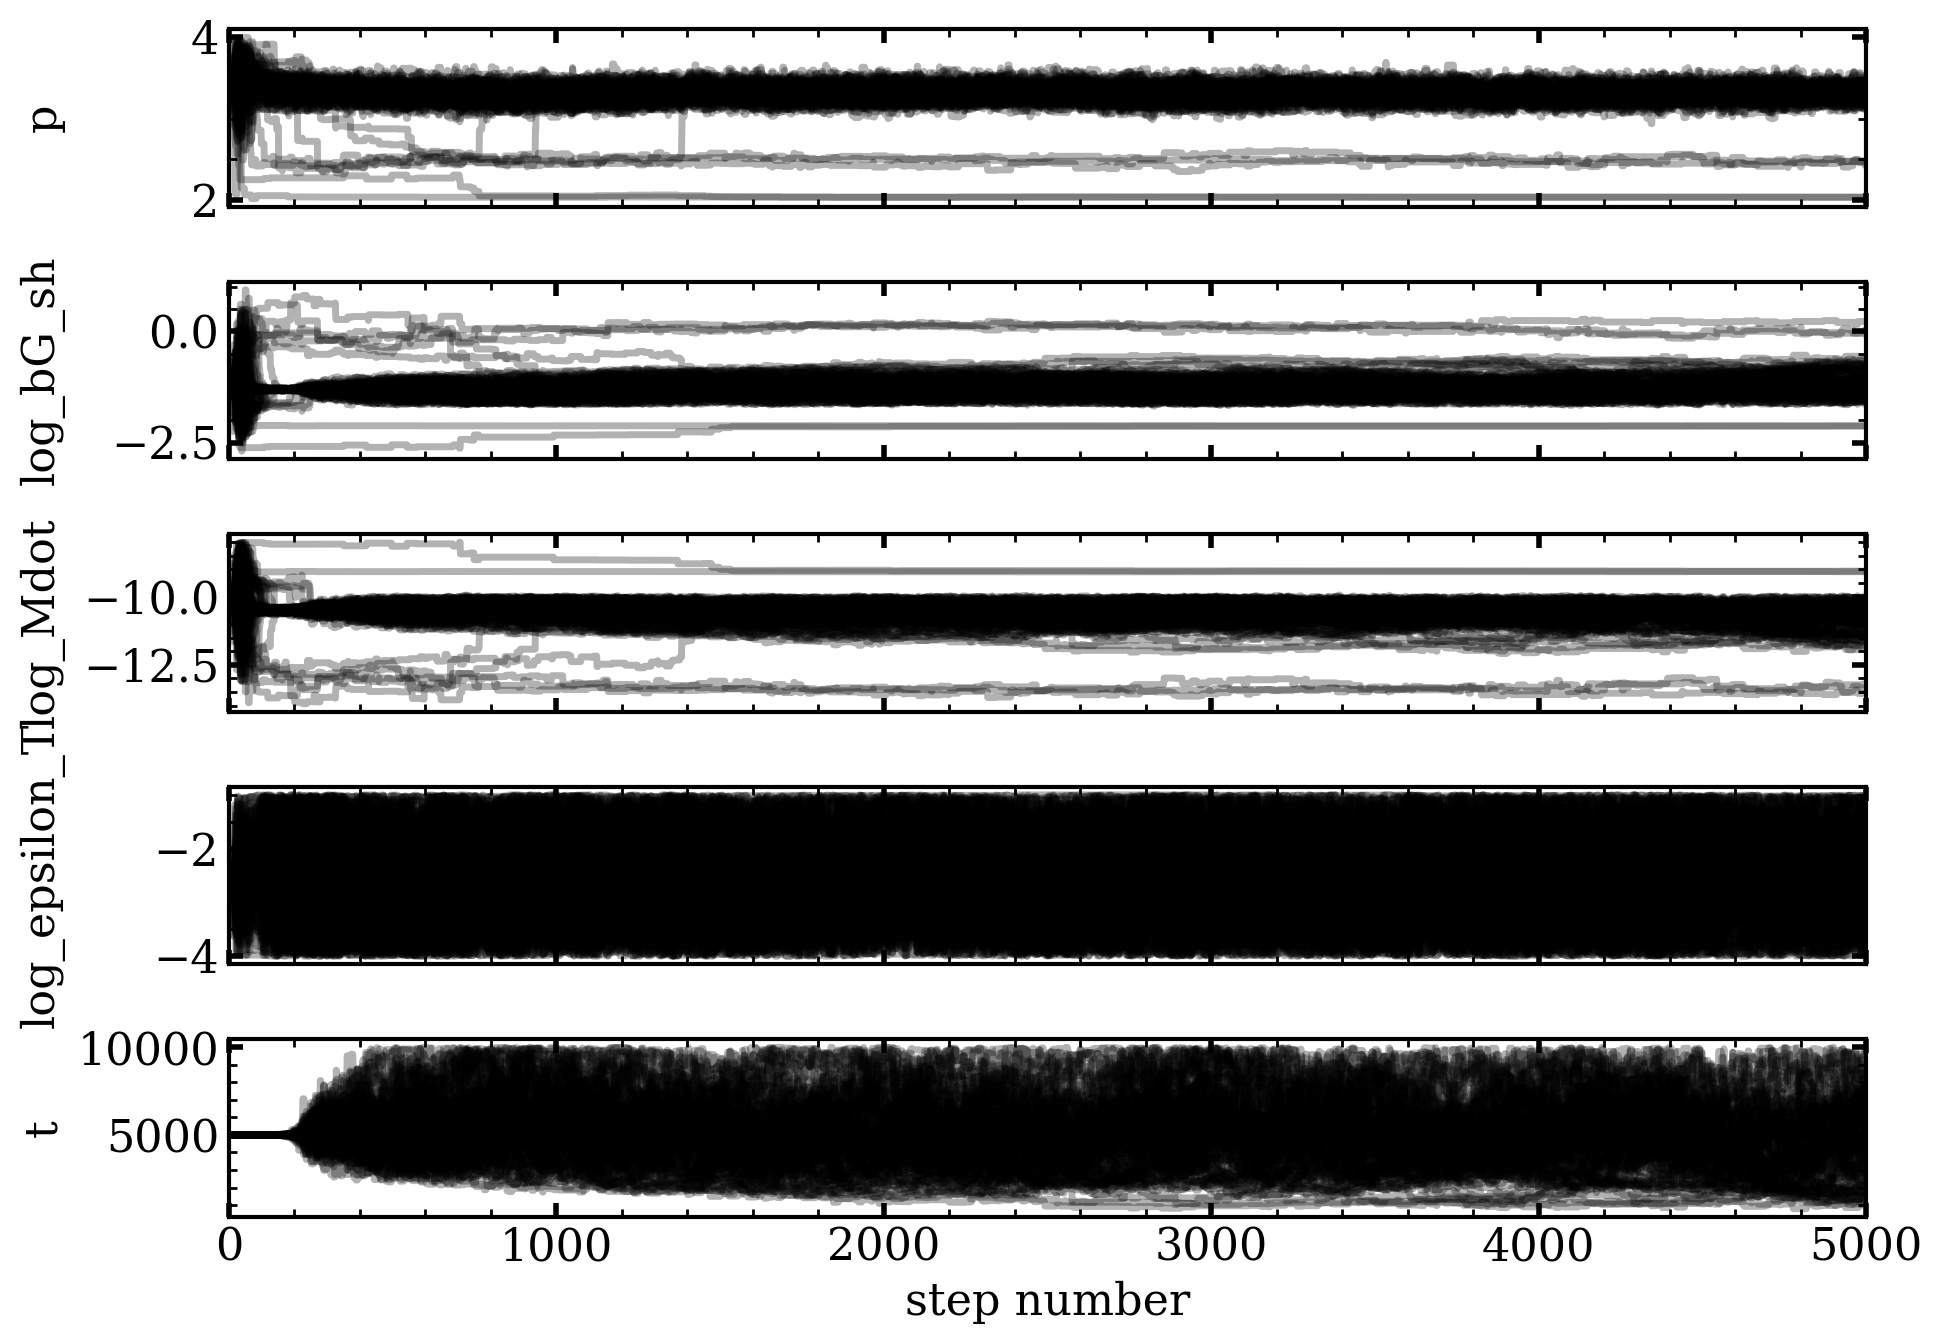

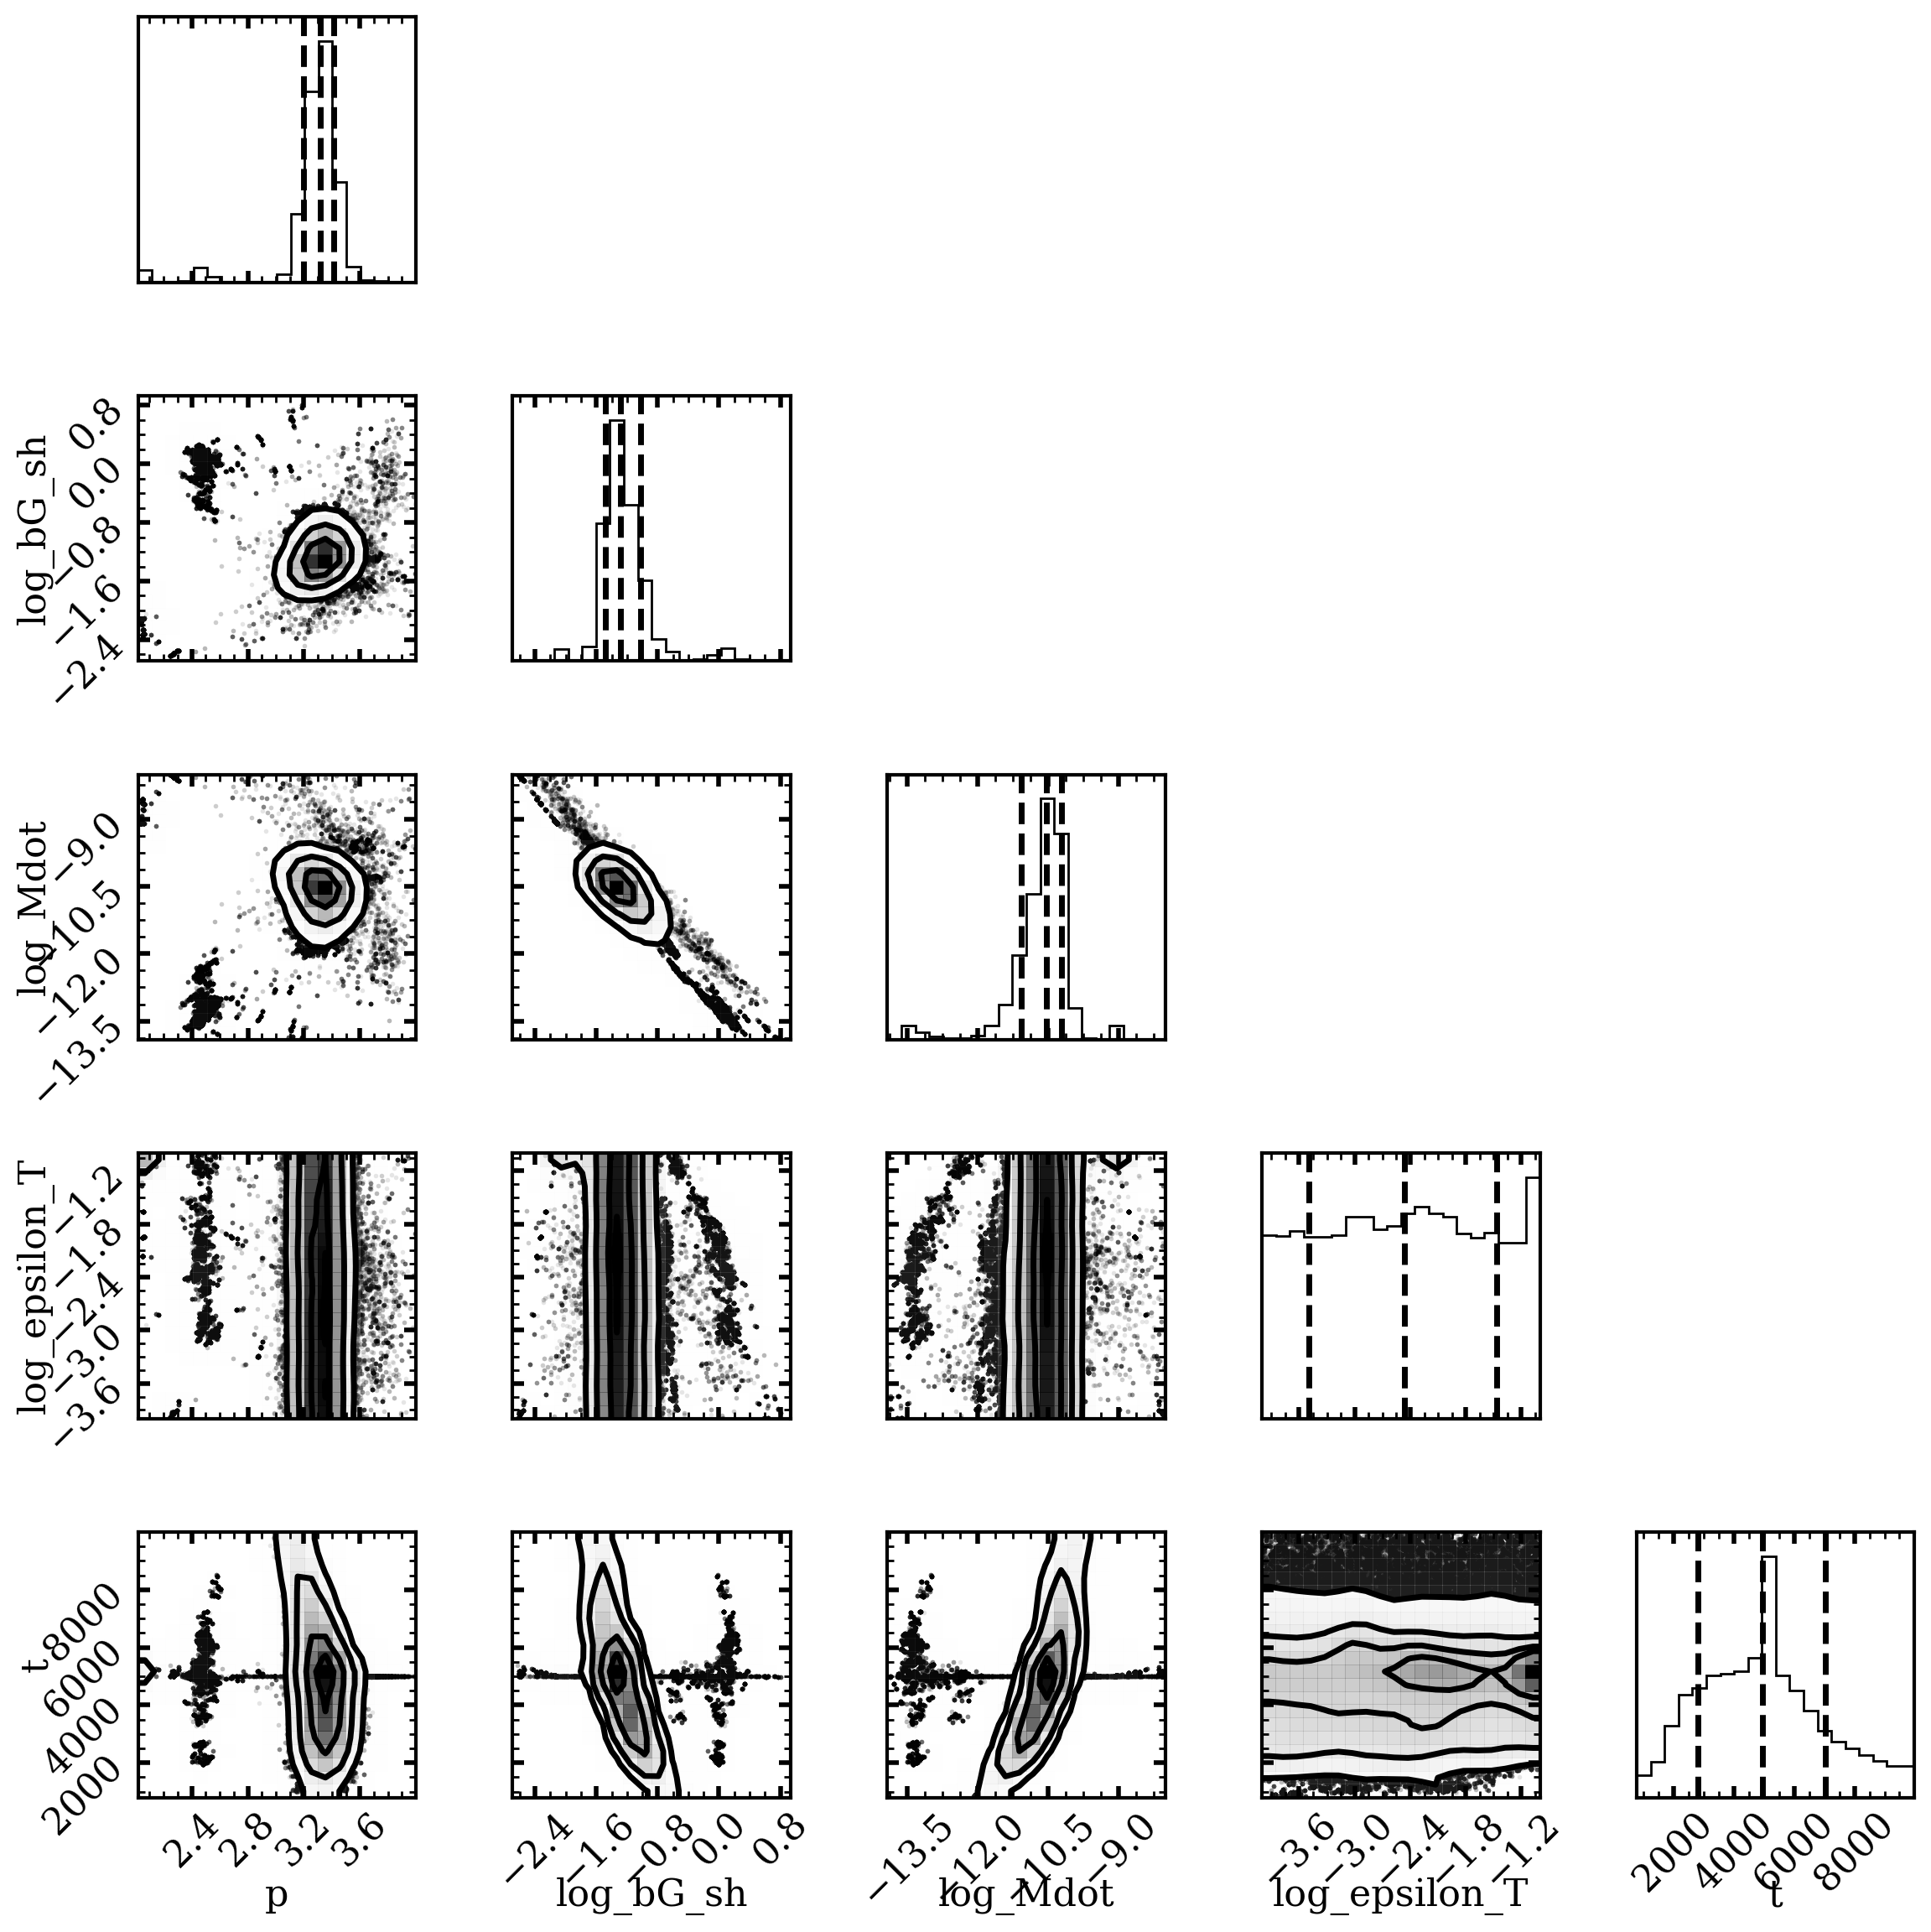

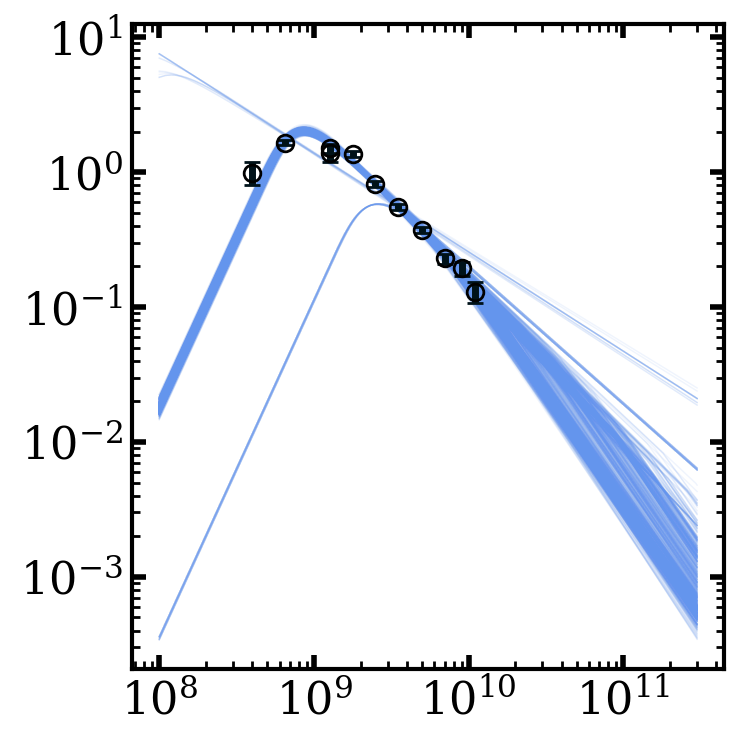

In [8]:
from syncfit.analysis import plot_best_fit
from syncfit.analysis import plot_chains

lum_dist = cosmo.luminosity_distance(z)
nwalkers = 100
niter = 5_000

theta_init = [
    3.3, # p
    -1, #log_bG_sh
    -10, #log_Mdot
    -2.6, # log_epsilon_T
    5_000, # dt
]

fixed_values = dict(
    log_epsilon_e = -1,
)


for epoch_num in [2,5]:
    test = j1241[j1241.epoch_num == epoch_num]


    nu = (test.converted_freq.values*u.GHz).to(u.Hz).value # Hz
    flux = test.converted_flux.values # mJy
    flux_err = test.converted_flux_err.values # mJy
    
    pos, labels, emcee_args = model.unpack_util(theta_init, nu, flux, flux_err,
                                                    nwalkers, lum_dist=lum_dist)
    
    nwalkers, ndim = pos.shape
    
    with Pool(20) as pool:
        sampler = EnsembleSampler(
            nwalkers, ndim,
            lnprob,
            kwargs={"flux":flux, "nu":nu, "flux_err":flux_err},
            pool=pool
        )
    
        pos, prob, state = sampler.run_mcmc(pos, niter, progress=True)

    print(f"Epoch {epoch_num}:")
    for ii, key in enumerate(prior):
        lo, med, hi = np.quantile(sampler.flatchain[niter//2:, ii], [0.16, 0.5, 0.84])
        print(f"{key} = {med} (+{hi-med}, -{med-lo})")
        
    fig, ax = plot_chains(sampler, model.labels)
    fig.savefig(f"SDSSJ1241-e{int(epoch_num)}-chain.png")
    
    fig = corner.corner(
        sampler.flatchain[niter//2:], 
        labels=model.labels, 
        quantiles=[0.16, 0.5, 0.84], 
        show_title=True, 
        title_kwargs={"fontsize":12}, 
        smooth=1
    );
    fig.savefig(f"SDSSJ1241-e{int(epoch_num)}-corner.png")
    

    fig, _ = plot_best_fit(
        model, sampler, 
        nu, flux, flux_err, 
        lum_dist=lum_dist.cgs.value, 
        log_epsilon_e = fixed_values["log_epsilon_e"], 
        log_epsilon_B = np.log10(epsB(10**fixed_values["log_epsilon_e"], np.median(sampler.flatchain[2_000:,0])))
    )
    fig.savefig(f"SDSSJ1241-e{int(epoch_num)}-bestfit.png")
    